# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4700s 28us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

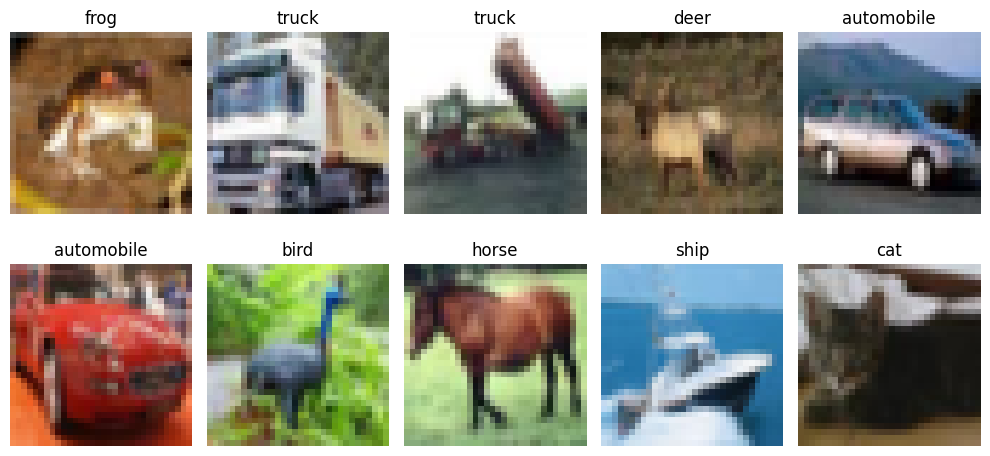

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

### Dataset Visualization

The CIFAR-10 dataset contains 10 classes:
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, and Truck.

The sample images above demonstrate the diversity of objects present in the dataset. Each image has dimensions of 32×32 pixels with 3 color channels (RGB).

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

### Data Preprocessing

Pixel values originally range from 0 to 255. Normalization scales these values to the range [0,1], which helps neural networks converge faster and improves training stability.

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [12]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2662 - loss: 2.0076 - val_accuracy: 0.3384 - val_loss: 1.8507
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3123 - loss: 1.8797 - val_accuracy: 0.3496 - val_loss: 1.8128
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3282 - loss: 1.8319 - val_accuracy: 0.3258 - val_loss: 1.8469
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3430 - loss: 1.7974 - val_accuracy: 0.3838 - val_loss: 1.7222
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3582 - loss: 1.7694 - val_accuracy: 0.3878 - val_loss: 1.7107
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3640 - loss: 1.7488 - val_accuracy: 0.3990 - val_loss: 1.6912
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3704 - loss: 1.7298 - val_accuracy: 0.4018 - val_loss: 1.6818
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3760 - loss: 1.7150 - val_accuracy: 0.

In [15]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4520 - loss: 1.5789
ANN Test Accuracy: 0.4519999921321869


### ANN Test Evaluation

The ANN achieved a test accuracy of 45.20% on the CIFAR-10 dataset. The relatively lower accuracy highlights the limitation of ANN in image classification, as it processes images as flattened vectors and cannot effectively capture spatial features.

### Early Stopping

Early Stopping is used to prevent overfitting by monitoring validation loss. Training stops automatically if validation loss does not improve for 3 consecutive epochs and restores the best model weights.

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [28]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4514 - loss: 1.5348 - val_accuracy: 0.4556 - val_loss: 1.4867
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5907 - loss: 1.1733 - val_accuracy: 0.6276 - val_loss: 1.0785
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6560 - loss: 0.9871 - val_accuracy: 0.6174 - val_loss: 1.1918
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6960 - loss: 0.8696 - val_accuracy: 0.6596 - val_loss: 0.9776
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7298 - loss: 0.7778 - val_accuracy: 0.6460 - val_loss: 1.0251
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7563 - loss: 0.6949 - val_accuracy: 0.6808 - val_loss: 0.9584
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7823 - loss: 0.6225 - val_accuracy: 0.6560 - val_loss: 1.0740
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8015 - loss: 0.5642 - val_accuracy: 

In [30]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)

print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7220 - loss: 1.1692
CNN Test Accuracy: 0.722000002861023


### CNN Analysis

The CNN achieved a test accuracy of 72.20% on the CIFAR-10 dataset, significantly outperforming the ANN model. The improvement demonstrates the effectiveness of convolutional layers in learning spatial and hierarchical image features.

## 📈 Compare Learning Curves

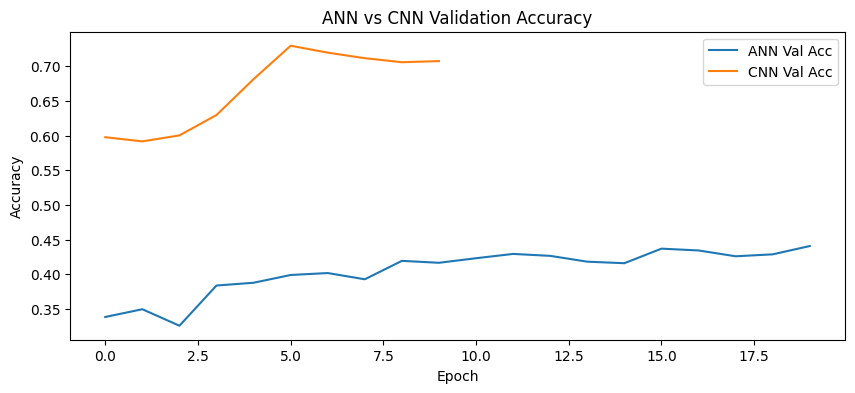

In [13]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

### Performance Comparison

The CNN consistently achieved higher validation accuracy than the ANN throughout training. The ANN reached a test accuracy of 43.09%, while the CNN achieved 69.13%. This improvement is due to the convolutional layers in CNNs, which preserve spatial information and learn meaningful image features more effectively than fully connected neural networks.

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [48]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy (%)": [
        round(ann_test_acc * 100, 2),
        round(cnn_test_acc * 100, 2)
    ]
})

display(comparison)

,Model,Test Accuracy (%)
0,ANN,45.2
1,CNN,72.2


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**